# UPSC Essay Evaluation Workflow: Parallelization (Fan-Out / Fan-In) in LangGraph

This notebook builds a LangGraph workflow that evaluates a UPSC (Union Public Service Commission) essay along three independent dimensions — language quality, depth of analysis, and clarity of thought — and then merges those three evaluations into a single aggregated result.

## The pattern: fan-out, parallel evaluation, fan-in

The graph built at the bottom of this notebook (`graph.add_edge(START, ...)` repeated three times, followed by three edges into `final_evaluation`) is a **fan-out / fan-in** (parallelization) pattern:

- **Fan-out**: `START` has an edge to each of `evaluate_language`, `evaluate_analysis`, and `evaluate_thought`. Because all three edges originate from the same node, LangGraph schedules all three target nodes to run in the same super-step — they execute concurrently rather than one after another.
- **Independent work**: each of the three nodes receives the same input (the essay) and does unrelated work — one judges language, one judges analytical depth, one judges clarity of thought. None of them depends on the others' output, which is exactly the condition under which parallel execution is safe and beneficial: no node needs to wait on a sibling.
- **Fan-in**: each of the three nodes also has an edge into a single `final_evaluation` node. LangGraph waits until all incoming branches have completed before running the node they converge on, so `final_evaluation` only executes once all three evaluations are available in shared state.

## Why parallel independent evaluations make sense for essay grading

Essay grading rubrics typically score several unrelated dimensions (language, structure, argument quality, factual grounding, and so on). Because each dimension is judged independently of the others, evaluating them as three separate LLM calls has two benefits over one large "evaluate everything" prompt:

- Each call has a narrow, focused prompt, which tends to produce more reliable, on-topic feedback than a single prompt asking an LLM to juggle several rubrics at once.
- The calls have no data dependency on each other, so running them concurrently reduces wall-clock latency compared to running them one after another.

## How LangGraph enables this

Two mechanisms make the pattern work in this notebook:

1. **Multiple edges from one node.** Calling `graph.add_edge(START, node)` more than once with different target nodes fans control out to all of them; LangGraph runs any nodes that are only reachable via already-satisfied incoming edges in the same step, which is what makes the three evaluators run in parallel rather than sequentially.
2. **A reducer on shared state.** All three evaluator nodes write to the same state key, `individual_scores`, in the same super-step. Without a reducer, concurrent writes to the same key would conflict. Here, `individual_scores` is declared as `Annotated[list[int], operator.add]`, so LangGraph combines the three single-item lists returned by the parallel nodes by concatenating them (`operator.add` on lists is list concatenation), instead of one overwriting another. The other fields each node writes to (`language_feedback`, `analysis_feedback`, `clarity_feedback`) are distinct keys, so no reducer is needed for those — each node simply owns its own key.

The remaining markdown cells walk through the state schema, each node, the graph wiring, compilation, and the final invocation in detail.

### Setup: imports

This cell imports every dependency the workflow needs:

- `StateGraph`, `START`, `END` from `langgraph.graph` — the graph builder class and the two sentinel nodes that mark the entry and exit points of the graph.
- `ChatOpenAI` from `langchain_openai` — the chat model wrapper used to call an OpenAI model.
- `load_dotenv` from `dotenv` — loads the OpenAI API key (and any other secrets) from a `.env` file into the process environment.
- `TypedDict`, `Annotated` from `typing` — used to define the graph's shared state schema and to attach a reducer to one of its fields.
- `BaseModel`, `Field` from `pydantic` — used to define a structured output schema for the LLM's evaluation responses.
- `operator` — supplies `operator.add`, which will be used as a reducer so that scores produced by parallel nodes accumulate into a single list instead of overwriting one another.

In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

### Loading credentials and instantiating the model

`load_dotenv()` reads the `.env` file so that the OpenAI API key is available as an environment variable. `model = ChatOpenAI(model='gpt-4o-mini')` creates the chat model instance that every node in this workflow will call, either directly or through its structured-output wrapper.

In [5]:
load_dotenv()
model = ChatOpenAI(model='gpt-4o-mini')

### Structured output schema for evaluations

`EvaluationSchema` is a Pydantic `BaseModel` that defines the shape every evaluator LLM call must return:

- `feedback: str` — free-text detailed feedback for the essay.
- `score: int` — a score out of 10, constrained with `Field(..., ge=0, le=10)` so Pydantic validates that the model's score falls within the 0–10 range.

This schema is reused by all three evaluator nodes later in the notebook — each one asks a different question (language, analysis, clarity) but all three responses are parsed into this same `feedback` / `score` shape.

In [7]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedbackfor the essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)

### Binding structured output to the model

`structured_model = model.with_structured_output(EvaluationSchema)` wraps `model` so that every `.invoke(...)` call on `structured_model` returns a parsed `EvaluationSchema` instance (with `.feedback` and `.score` attributes) instead of a raw chat message. This removes the need to manually parse the LLM's text response — LangChain handles getting the model to produce output conforming to the schema and validates/parses it into the Pydantic object.

In [9]:
structured_model = model.with_structured_output(EvaluationSchema)

### Sample essay (high quality)

`essay` holds a well-written, fluent sample essay on "India in the Age of AI." This is the text that will actually flow through the compiled graph later in the notebook, giving the evaluator nodes a realistic, well-structured piece of writing to score.

In [10]:
essay = """India in the Age of AI
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address India’s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

India’s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.

In conclusion, India in the age of AI is a story in the making — one of opportunity, responsibility, and transformation. The decisions we make today will not just determine India’s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""

### Sample essay (deliberately weak language)

`essay2` holds a second sample essay on the same topic, written with poor grammar and broken English on purpose. It is defined here for contrast/experimentation with the evaluation prompts, but it is not the essay actually passed into the compiled workflow later in the notebook — only `essay` is used in the final `workflow.invoke(...)` call.

In [11]:
essay2 = """India and AI Time

Now world change very fast because new tech call Artificial Intel… something (AI). India also want become big in this AI thing. If work hard, India can go top. But if no careful, India go back.

India have many good. We have smart student, many engine-ear, and good IT peoples. Big company like TCS, Infosys, Wipro already use AI. Government also do program “AI for All”. It want AI in farm, doctor place, school and transport.

In farm, AI help farmer know when to put seed, when rain come, how stop bug. In health, AI help doctor see sick early. In school, AI help student learn good. Government office use AI to find bad people and work fast.

But problem come also. First is many villager no have phone or internet. So AI not help them. Second, many people lose job because AI and machine do work. Poor people get more bad.

One more big problem is privacy. AI need big big data. Who take care? India still make data rule. If no strong rule, AI do bad.

India must all people together – govern, school, company and normal people. We teach AI and make sure AI not bad. Also talk to other country and learn from them.

If India use AI good way, we become strong, help poor and make better life. But if only rich use AI, and poor no get, then big bad thing happen.

So, in short, AI time in India have many hope and many danger. We must go right road. AI must help all people, not only some. Then India grow big and world say "good job India"."""

### Prototyping a single evaluation call before building the graph

Before wiring up the graph, this cell prototypes what one evaluator node will do: it builds a plain f-string prompt asking the model to "evaluate the language quality" of `essay` and assign a score out of 10, then calls `structured_model.invoke(prompt)`. The output shown below the cell is an `EvaluationSchema` instance with populated `feedback` and `score` fields — confirming the structured-output wiring works before it gets embedded inside a node function. The `evaluate_language` node defined later reuses this exact prompt pattern.

In [14]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
structured_model.invoke(prompt)

EvaluationSchema(feedback="The essay presents a well-structured and articulate discourse on India's position in the age of AI. The language is formal and appropriately academic, which suits the topic. The introduction effectively sets the stage for the discussion, outlining both the potential benefits and challenges related to AI in India. Each paragraph logically flows into the next, with clear transitions that help maintain the essay's coherence. The use of specific examples, such as the roles of IITs, TCS, and applications in agriculture and healthcare, strengthens the argument and illustrates India's capabilities and the challenges it faces. \n\nHowever, there are areas for improvement. The essay could benefit from more detailed data or statistics to support claims regarding the skills of the workforce or the effectiveness of AI applications. Additionally, while the challenges are mentioned, there could be a deeper exploration of potential solutions or strategies to address these c

### State schema: `UPSCState`

`UPSCState` is a `TypedDict` defining every key the graph reads from and writes to as it runs:

- `essay: str` — the input essay text, set once at invocation and read by all three evaluator nodes.
- `language_feedback: str`, `analysis_feedback: str`, `clarity_feedback: str` — each written by exactly one evaluator node (`evaluate_language`, `evaluate_analysis`, `evaluate_thought` respectively). Because each node owns a distinct key, no reducer is required for these three fields — there is no concurrent-write conflict to resolve.
- `overall_feedback: str` — written once by `final_evaluation`, holding the LLM-generated summary of the three feedback fields.
- `individual_scores: Annotated[list[int], operator.add]` — written by all three evaluator nodes in the same super-step. Since they run in parallel and each returns a single-element list (for example `{'individual_scores': [output.score]}`), this field is annotated with `operator.add` as its reducer so LangGraph concatenates the three single-item lists into one three-item list rather than letting one write clobber another.
- `avg_score: float` — written once by `final_evaluation`, computed from `individual_scores`.

This schema is the backbone that lets three concurrently running nodes safely contribute to shared state and then lets a fourth node read all of their contributions once they have all landed.

In [15]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

### Node: `evaluate_language`

This node function reads `state["essay"]`, builds a prompt asking the model to evaluate the essay's language quality and assign a score out of 10, and calls `structured_model.invoke(prompt)` to get back a parsed `EvaluationSchema` object (`output`).

It returns a partial state update: `{'language_feedback': output.feedback, 'individual_scores': [output.score]}`. The `individual_scores` value is a single-element list rather than a bare integer, because that key's reducer (`operator.add`) is defined at the list level — each parallel node must contribute a list so the reducer can concatenate the contributions from all three evaluator nodes into one combined list.

In [16]:
def evaluate_language(state: UPSCState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

### Node: `evaluate_analysis`

Structurally identical to `evaluate_language`, but the prompt instead asks the model to evaluate "the depth of analysis" of the essay. It calls the same `structured_model` and returns `{'analysis_feedback': output.feedback, 'individual_scores': [output.score]}`. This node writes to its own dedicated feedback key (`analysis_feedback`) and contributes its score to the same shared, reducer-backed `individual_scores` list as `evaluate_language`.

In [17]:
def evaluate_analysis(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

### Node: `evaluate_thought`

The third and final evaluator node, following the same shape again: its prompt asks the model to evaluate "the clarity of thought" of the essay, and it returns `{'clarity_feedback': output.feedback, 'individual_scores': [output.score]}`. Together, `evaluate_language`, `evaluate_analysis`, and `evaluate_thought` are the three parallel branches of the fan-out — each independently invokes the LLM on the same essay with a different evaluation criterion.

In [18]:
def evaluate_thought(state: UPSCState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

### Node: `final_evaluation` (the fan-in / reduce node)

This node runs only after all three evaluator nodes have completed, since it is the convergence point of all three of their outgoing edges. It does two things:

1. **Summarized feedback**: builds a prompt embedding `state["language_feedback"]`, `state["analysis_feedback"]`, and `state["clarity_feedback"]`, asking the (non-structured) `model` to produce a single summarized feedback paragraph. This call uses plain `model.invoke(prompt).content` rather than `structured_model`, since a free-text summary — not a validated score — is what's needed here.
2. **Average score**: computes `avg_score = sum(state['individual_scores']) / len(state['individual_scores'])`, averaging the three scores that were concatenated into `individual_scores` by the reducer.

It returns `{'overall_feedback': overall_feedback, 'avg_score': avg_score}`, populating the two state keys that only this node writes to.

In [19]:
def final_evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

### Building and wiring the graph

`graph = StateGraph(UPSCState)` creates the graph builder bound to the state schema defined earlier. Each node function is registered with `graph.add_node(name, function)`.

The edges implement the fan-out / fan-in structure:

- `graph.add_edge(START, 'evaluate_language')`, `graph.add_edge(START, 'evaluate_analysis')`, `graph.add_edge(START, 'evaluate_thought')` — three separate edges from the same `START` node. This is the fan-out: all three evaluator nodes become runnable as soon as the graph starts, and LangGraph executes them concurrently in the same super-step since none of them depends on another's output.
- `graph.add_edge('evaluate_language', 'final_evaluation')`, `graph.add_edge('evaluate_analysis', 'final_evaluation')`, `graph.add_edge('evaluate_thought', 'final_evaluation')` — three edges converging on `final_evaluation`. This is the fan-in: LangGraph will not run `final_evaluation` until all three incoming edges have been satisfied, guaranteeing `language_feedback`, `analysis_feedback`, `clarity_feedback`, and the full `individual_scores` list are all present in state before it executes.
- `graph.add_edge('final_evaluation', END)` — terminates the graph after the aggregation step.

`workflow = graph.compile()` compiles the graph definition into a runnable object (`workflow`) that can be invoked, streamed, or visualized.

In [20]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

### Visualizing the compiled graph

Displaying `workflow` in a Jupyter cell renders its graphical representation, showing `START` branching into the three parallel evaluator nodes, all three converging on `final_evaluation`, and a single edge from there to `END`. This is a visual confirmation of the fan-out / fan-in structure described above.

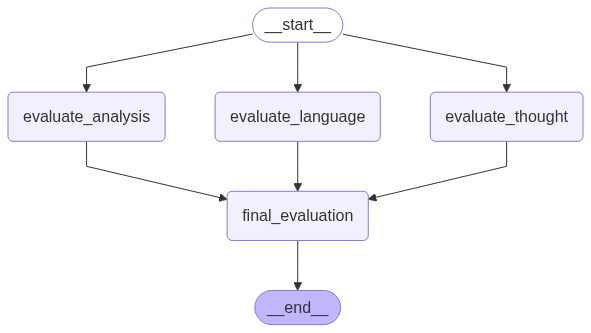

In [21]:
workflow

### Running the workflow and reading the output

`intial_state = {'essay': essay}` supplies only the `essay` key — every other key in `UPSCState` (`language_feedback`, `analysis_feedback`, `clarity_feedback`, `overall_feedback`, `individual_scores`, `avg_score`) starts unset and is populated as the graph runs.

`workflow.invoke(intial_state)` runs the compiled graph to completion and returns the final state dictionary. In the recorded output:

- `language_feedback`, `analysis_feedback`, and `clarity_feedback` each hold the free-text feedback produced by their respective evaluator node.
- `individual_scores` is `[7, 8, 8]` — the three integers contributed by `evaluate_language`, `evaluate_analysis`, and `evaluate_thought`, concatenated together by the `operator.add` reducer regardless of the order in which the parallel nodes actually finished.
- `overall_feedback` is the LLM-generated summary paragraph produced by `final_evaluation` from the three feedback fields.
- `avg_score` is `7.666...`, the arithmetic mean of `individual_scores`, computed by `final_evaluation`.

The returned dictionary also still contains the original `essay` key, since LangGraph state updates are merged into the existing state rather than replacing it.

In [22]:
intial_state = {
    'essay': essay
}

workflow.invoke(intial_state)

{'essay': "India in the Age of AI\nAs the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture — one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.\n\nIndia's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for 

## Summary: the map-reduce evaluation pattern

This notebook demonstrates a **map-reduce-style parallelization** pattern in LangGraph:

- **Map**: the same input (the essay) is dispatched to multiple independent nodes (`evaluate_language`, `evaluate_analysis`, `evaluate_thought`) via multiple edges out of `START`, each applying a different evaluation function to the same data.
- **Reduce**: the results are gathered back together at a single downstream node (`final_evaluation`), reached via multiple converging edges, with a reducer (`operator.add` on `individual_scores`) resolving the concurrent writes made by the parallel branches into one combined value, and the reduce node itself computing derived results (the average score and the summarized feedback) from the gathered pieces.

## Practical applications beyond essay grading

The same shape — fan-out to independent evaluators/processors over shared input, fan-in to an aggregator, with reducers handling concurrent writes to shared keys — applies to any task that decomposes into independent sub-judgments or sub-computations over the same input, for example:

- **Multi-criteria content moderation**: separate nodes checking a piece of content for toxicity, spam, and policy violations in parallel, aggregated into a single moderation decision.
- **Resume or application screening**: parallel nodes scoring skills match, experience relevance, and communication quality, combined into an overall candidate score.
- **Code review automation**: parallel nodes checking style, security issues, and test coverage on the same diff, merged into a single review summary.
- **Ensemble LLM judging**: the same input evaluated by several different prompts (or several different models) in parallel, with the reduce step averaging or voting across their scores — directly analogous to how this notebook averages three independent LLM-generated scores.

In all of these cases, the same two LangGraph mechanisms shown here apply: multiple edges from one source node to fan work out in parallel, and reducers on shared state keys to safely merge the concurrent contributions back into one value before the aggregation node runs.